## **GMM - Gaussian Mixture Model**
Goals: 
- GMM - Definition
- Estimate Parameter Process
- What is the shape of $b^i_j$
- How the Weights ($b^i_j$) apply to the data points
- The goal behind of GMM
- What is the difference between the two weights $b^i_j$ and $\phi_j$
- Implementation in python
--- 

#### **GMM - Definition**

A **Gaussian Mixture Model (GMM)** is a probabilistic model that assumes all data points are generated from a mixture of a finite number of Gaussian (Normal) distributions with unknown parameters. Unlike K-Means, which performs "hard clustering" (assigning a point to exactly one cluster), GMM performs **"soft clustering,"** providing the probability that each data point belongs to each cluster.

### 1. Core Components
A GMM is defined by three key parameters for each of the $K$ clusters:
*   **Mean ($\mu$):** The center of the Gaussian distribution.
*   **Covariance ($\Sigma$):** The shape, spread, and orientation of the cluster (can be spherical, elliptical, or stretched).
*   **Mixing Weight ($\pi$):** The proportion/importance of each cluster in the overall dataset.

### 2. The Mathematical Intuition
The probability density function for a GMM is a weighted sum of $K$ Gaussian densities:
$$p(x) = \sum_{k=1}^{K} \pi_k \mathcal{N}(x | \mu_k, \Sigma_k)$$
Where $\sum \pi_k = 1$. This allows the model to represent complex, multi-modal distributions that a single Gaussian cannot.

### 3. The Learning Algorithm: Expectation-Maximization (EM)
Since we do not know which point belongs to which cluster (latent variables), GMMs are trained using the **EM algorithm**, an iterative process:

1.  **Initialization:** Randomly initialize the means, covariances, and mixing weights (often using K-Means results).
2.  **E-Step (Expectation):** Calculate the "responsibility" ($\gamma$)—the posterior probability that each cluster $k$ is responsible for generating data point $x_i$. This is essentially calculating the probability of membership.
3.  **M-Step (Maximization):** Update the parameters ($\mu, \Sigma, \pi$) to maximize the likelihood of the data, using the responsibilities calculated in the E-step as weights.
4.  **Iteration:** Repeat the E and M steps until the change in the log-likelihood falls below a certain threshold (convergence).

### 4. GMM vs. K-Means
| Feature | K-Means | GMM |
| :--- | :--- | :--- |
| **Cluster Type** | Hard Assignment (0 or 1) | Soft Assignment (Probabilities) |
| **Cluster Shape** | Strictly Spherical | Elliptical/Flexible (via Covariance) |
| **Complexity** | Lower (Faster) | Higher (More parameters to estimate) |
| **Assumptions** | Assumes clusters are equal size/shape | Can model overlapping and varying shapes |

### 5. Advantages and Disadvantages
**Advantages:**
*   **Flexibility:** By adjusting the covariance matrix, GMM can model clusters of various sizes and orientations (elliptical).
*   **Uncertainty Estimation:** Provides a measure of confidence for each assignment via probabilities.
*   **Generative Model:** Can be used to generate new, synthetic data points that follow the learned distribution.

**Disadvantages:**
*   **Computationally Intensive:** Much slower than K-Means on large datasets due to the EM iterations and covariance calculations.
*   **Local Optima:** The EM algorithm is sensitive to initialization and can get stuck in local maxima.
*   **Overfitting:** If the number of clusters ($K$) or the complexity of the covariance matrix is too high, the model may overfit the noise in the data.

---

### **Estimate parameters process**

Here is the step-by-step breakdown:


### [1] Initialization (The "Guessing" Phase)
Before the math starts, you need a starting point. Since the algorithm doesn't know where the clusters are, you must provide an initial guess.
*   **Parameters to guess:** You pick starting values for the centers ($\mu_1, \mu_2$) and the spreads ($\sigma^ 2_1, \sigma^2_2$).
*   **Mixing Weights ($\phi$):** You assume both clusters are equally important at the start, so $\phi_1 = 0.5$ and $\phi_2 = 0.5$. (In a $K$-cluster model, you would set them to $1/K$).


### [2] The E-Step (The "Assignment" Phase)
Now that you have "guesses," you look at your actual data points ($c_i$) and try to figure out which cluster they likely belong to. This is called **Expectation** because you are calculating the *expected* membership.

*   **Part A (Likelihood):** For every single data point $c_i$, you calculate how well it fits into Cluster 1 and Cluster 2 separately using the Gaussian formula: $f(c_i | \mu_j, \sigma^2_j)$.
    *   *Translation:* "If Cluster 1 were the true cluster, how likely is it that we would see this point?"
*   **Part B (Responsibility/Bayes' Rule):** You use Bayes' Rule to calculate $b^i_j$. This is the **membership score**. It isn't just "Yes" or "No"; it is a probability between 0 and 1.
    *   **The Formula:** $b^i_j = \frac{\text{Likelihood of point in cluster } j \times \text{Weight of cluster } j}{\text{Total likelihood across all clusters}}$
      = $b^i_j = \frac{f(c_i|\mu_j, \; \sigma_j^2) \phi_j}{f(c_i|\mu_1, \; \sigma_1^2) \phi_1 + f(c_i|\mu_2, \; \sigma_2^2) \phi_2}.$
    *   *Translation:* "Given that this point looks like it belongs to Cluster 1, what is the probability it actually belongs to Cluster 1 versus Cluster 2?"


### [3] The M-Step (The "Update" Phase)
Now that you have assigned "weights" ($b^i_j$) to every point, you use those weights to **re-calculate** your parameters. This is called **Maximization** because you are adjusting the parameters to maximize the likelihood of the data.

*   **Updating $\mu_j$ (The New Center):** You calculate a **weighted average**. Instead of treating all points equally, points with a high $b^i_j$ (high membership score) pull the center toward them more strongly.
    $$\mu_j = \frac{\sum (\text{weight} \times \text{point value})}{\sum \text{weights}}$$
*   **Updating $\sigma^2_j$ (The New Spread):** You calculate the **weighted variance**. You measure how far points are from the *new* $\mu_j$, weighted by their membership score.
*   **Updating $\phi_j$ (The New Cluster Size):** You update the importance of the cluster. If most points were assigned to Cluster 1 in the E-step, $\phi_1$ will increase. It is simply the average responsibility across all $N$ points.


### [4] Iteration (The "Looping" Phase)
The algorithm repeats **Step 2** and **Step 3** over and over.
*   In each loop, the centers ($\mu$) move, the spreads ($\sigma^2$) adjust, and the membership scores ($b^i_j$) become more certain.
*   **Convergence:** You stop when the parameters $\mu$ and $\sigma$ stop changing significantly (when the change is less than a tiny threshold $\epsilon$). This means the algorithm has "settled" on the best possible fit.


### [5] Final Output (The Result)
Once the loop stops, the algorithm provides you with two things:
1.  **The Model:** The final, optimized values for $\mu_j$, $\sigma^2_j$, and $\phi_j$.
2.  **The Membership Scores ($b^i_j$):** For every data point in your dataset, you now have a definitive probability score telling you exactly how much that point belongs to Cluster 1 vs. Cluster 2.

--- 

### **What is the shape of $b^i_j$**


Specifically, $b^i_j$ is a **matrix of responsibilities** (often called the "posterior probability matrix"). If you have $N$ data points and $K$ clusters:

*   The number of rows = $N$ (one for each sample).
*   The number of columns = $K$ (one for each cluster).

### To be precise:
For every single sample $i$, there is a set of values $\{b^i_1, b^i_2, \dots, b^i_K\}$. 

**Two rules always apply to these values for any given sample $i$:**
1.  **Range:** Each value $b^i_j$ is between $0$ and $1$.
2.  **Summation:** For a specific sample $i$, the sum of its responsibilities across all clusters must equal $1$:
    $$\sum_{j=1}^{K} b^i_j = 1$$

### Example:
If you have **3 samples** and **2 clusters**, your $b$ matrix looks like this:

| Sample ($i$) | Cluster 1 ($b^i_1$) | Cluster 2 ($b^i_2$) | Sum (must be 1) |
| :--- | :--- | :--- | :--- |
| **Sample 1** | $0.95$ | $0.05$ | $1.0$ |
| **Sample 2** | $0.40$ | $0.60$ | $1.0$ |
| **Sample 3** | $0.02$ | $0.98$ | $1.0$ |

*   **Sample 1** is almost certainly in Cluster 1.
*   **Sample 2** is "uncertain" (it sits on the boundary).
*   **Sample 3** is almost certainly in Cluster 2.

When you perform the **M-step**, you use these $N \times K$ values to "weight" the data points when calculating the new $\mu$, $\sigma^2$, and $\phi$.

---

### **How the Weights ($b^i_j$) apply to the data points**

To "weight" the data points means that instead of treating every point as an equal contributor to the cluster's properties, you treat them based on their **responsibility** ($b^i_j$). 

A point with a high $b^i_j$ (close to 1) has a massive influence on that cluster's new center and spread. A point with a low $b^i_j$ (close to 0) is almost ignored by that cluster.

Here is how the weighting works mathematically for each parameter:


### 1. Weighting the Mean ($\mu_j$)
The goal is to find the new center of Cluster $j$. We use a **Weighted Average**.

**Standard (Unweighted) Average:**
$$\mu = \frac{x_1 + x_2 + x_3}{3}$$
*(Every point has a weight of $1/3$)*

**Weighted Average (EM Step):**
$$\mu_j = \frac{\sum_{i=1}^{N} (b^i_j \cdot x_i)}{\sum_{i=1}^{N} b^i_j}$$

*   **The Numerator ($\sum b^i_j \cdot x_i$):** You multiply each point $x_i$ by its responsibility $b^i_j$. If a point has a $0.99$ score, it keeps $99\%$ of its "pulling power." If it has a $0.01$ score, its contribution to the sum becomes negligible.
*   **The Denominator ($\sum b^i_j$, also called $N_j$):** Since we scaled the numerator down by multiplying by small decimals, we must divide by the sum of those weights to "re-normalize" the result so the scale remains correct.


### 2. Weighting the Variance ($\sigma^2_j$)
The goal is to find how much the cluster spreads out around the **new** center. We use a **Weighted Variance**.

**Standard (Unweighted) Variance:**
$$\sigma^2 = \frac{\sum (x_i - \mu)^2}{N}$$

**Weighted Variance (EM Step):**
$$\sigma^2_j = \frac{\sum_{i=1}^{N} b^i_j \cdot (x_i - \mu_j^{new})^2}{\sum_{i=1}^{N} b^i_j}$$

*   **The Logic:** We calculate the squared distance from the *new* mean $(x_i - \mu_j^{new})^2$. 
*   We then multiply that squared distance by $b^i_j$. 
*   If a point is far away from the center but has a very low responsibility ($b^i_j \approx 0$), its "outlier" status is ignored by this cluster. It won't blow up the variance.


### Summary Visualization
Imagine you are trying to find the center of gravity for a group of people:

*   **Unweighted:** You treat every person as if they weigh exactly 70kg. The center is just the geometric middle of their positions.
*   **Weighted (EM):** You assign each person a "weight" based on how much they "belong" to your group. A person standing far away but who has a $99\%$ membership score acts like a heavy anchor, pulling the center toward them. A person standing right in the middle but who only has a $1\%$ membership score is treated like a tiny feather; they don't move the center at all.

---

### **The goal behind of GMM:**

Assuming a 1-D data, the ***maximum likelihood criterion*** is the weighted sum of several univariate normal distributions:

$f_C = \sum_{j=1}^k \phi_j f_{\mathbf{\mu_j, \;\sigma_j}}$, 

where C are the 1-D data points, j = 1,...,k are the number of clusters, and $\phi_j$ is the scale parameter (i.e., the weight each cluster gets in the sum). The parameters $\mu_j, \sigma_j, \phi_j$ are estimated using the EM algorithm.

---

### **What is the difference between the two weights $b^i_j$ and $\phi_j$**

The best way to think about it is:
*   $b^i_j$ is a **per-sample** weight (How much does *this specific point* belong to *this cluster*?).
*   $\phi_j$ is a **per-cluster** weight (How much does *this entire cluster* contribute to the *whole dataset*?).

Here is the breakdown of the difference:

### 1. The Dimensions (The most important difference)
*   **$b^i_j$ is a Matrix ($N \times K$):** There are $N$ different values for every cluster. If you have 1,000 points and 2 clusters, you have 2,000 total $b$ values. Each value tells you the "membership score" of one specific point.
*   **$\phi_j$ is a Vector ($K$):** There is only **one** value per cluster. If you have 2 clusters, you only have 2 $\phi$ values ($\phi_1$ and $\phi_2$).

### 2. The Mathematical Relationship
The $\phi_j$ is actually the **average** of all the $b^i_j$ values for that cluster across all samples.

$$\phi_j = \frac{1}{N} \sum_{i=1}^{N} b^i_j$$

In plain English: To find the importance of Cluster 1 ($\phi_1$), you take the membership scores ($b^i_1$) of every single point in your dataset, add them up, and divide by the total number of points.

### 3. Conceptual Difference (An Analogy)
Imagine a classroom of $N$ students. Some students are "Math enthusiasts" and some are "History enthusiasts."

*   **$b^i_j$ (The Student's Interest):** This is how much **Student $i$** likes **Subject $j$**. 
    *   *Student 1 might be 90% Math / 10% History.*
    *   *Student 2 might be 20% Math / 80% History.*
    *   This is a list of individual preferences.

*   **$\phi_j$ (The Subject's Prevalence):** This is the **total proportion** of interest in the whole class for that subject.
    *   If you sum up all the "Math" scores from every student and divide by the total number of students, you get $\phi_{math}$. 
    *   This tells you: "In this classroom, 60% of the total 'interest' lies in Math."

### Summary Table

| Feature | $b^i_j$ (Responsibility) | $\phi_j$ (Mixing Weight) |
| :--- | :--- | :--- |
| **Scope** | Individual (Point-level) | Global (Cluster-level) |
| **What it represents** | Probability that point $i$ belongs to cluster $j$. | The probability that a randomly selected point comes from cluster $j$. |
| **Size** | $N \times K$ (Large) | $K$ (Small) |
| **Role in Formula** | Weights the contribution of each $x_i$ to $\mu$ and $\sigma^2$. | Weights the contribution of each Gaussian distribution to the total density $f_C$. |

---

### **Implementation in Python**

In [1]:
# standard
import numpy as np
import pandas as pd
import math

# visualization
import matplotlib.pyplot as plt

# machine learning
from sklearn import cluster, datasets, mixture

# instead of writing the E-step adn M-step manually, this class handles EM algorithm loop automatically, convergence checks, calculation of weights, means, and covariances.
from sklearn.mixture import GaussianMixture 

#### Step 1: Define the Gauss Probability Density Function

In [2]:
def gauss_pdf(x, mean, variance):
    s1 = 1 / (2 * math.pi * variance)
    s2 = np.exp(-(x - mean) ** 2 / (2 * variance))
    return s1 * s2

#### Step 2: Define the two means,and two variance, and samples

In [3]:
# Total samples, mean and variance
n_samples = 200
mean1,  var1 = -4, 1.2
mean2,  var2 =  0, 1.6

# create two normal distribution
c1 = np.random.normal(mean1, np.sqrt(var1), n_samples)
c2 = np.random.normal(mean2, np.sqrt(var2), n_samples)

# combine all samples together
C = np.array(list(c1) + list(c2))

# review 
pd.DataFrame(C).head(10)

,0
0,-5.891914
1,-3.055570
2,-1.174473
3,-5.087898
4,-6.695327
5,-4.249176
6,-4.133020
7,-4.214335
8,-4.221946
9,-5.257938


#### Step 3: plot the data

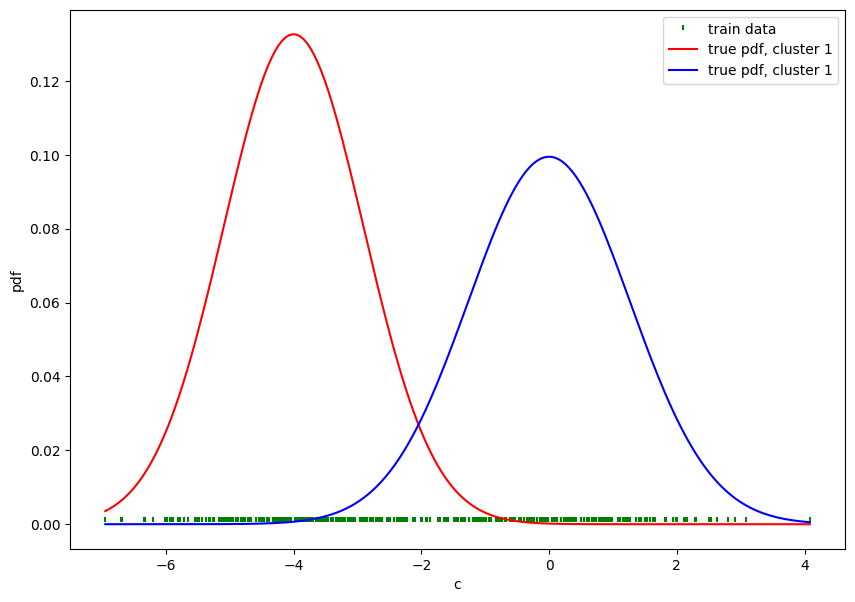

In [4]:
# create X - used to generate the pdf - probability density function
bins = np.linspace(np.min(C), np.max(C), 200)

plt.figure(figsize=(10,7))
# plot the training date 
plt.scatter(C, [0.0005]*len(C), color='g', s=15, marker=2, label='train data')

# plot the true two normal distributions
plt.plot(bins, gauss_pdf(bins, mean1, var1), color='r', label='true pdf, cluster 1')
plt.plot(bins, gauss_pdf(bins, mean2, var2), color='b', label='true pdf, cluster 1')

plt.xlabel('c')
plt.ylabel('pdf')
plt.legend()
plt.show()

#### Step 4: sklearn.mixture - GaussianMixture

In [5]:
# fit the model
gmm = GaussianMixture(n_components=2,
                      covariance_type='full',
                      random_state=42)

# predict new centroids
C = C[:, np.newaxis]
y_pred = gmm.fit_predict(C)

# get the means, covariance, and weights
means = gmm.means_
covariances = gmm.covariances_
weights = gmm.weights_

In [6]:
print(f'means: {means}')
print(f'covariances: {covariances}')
print(f'weights: {weights}')

means: [[-3.9138303 ]
 [ 0.20942248]]
covariances: [[[1.35748415]]

 [[1.51973058]]]
weights: [0.53326133 0.46673867]


#### Step 5: review the learning results

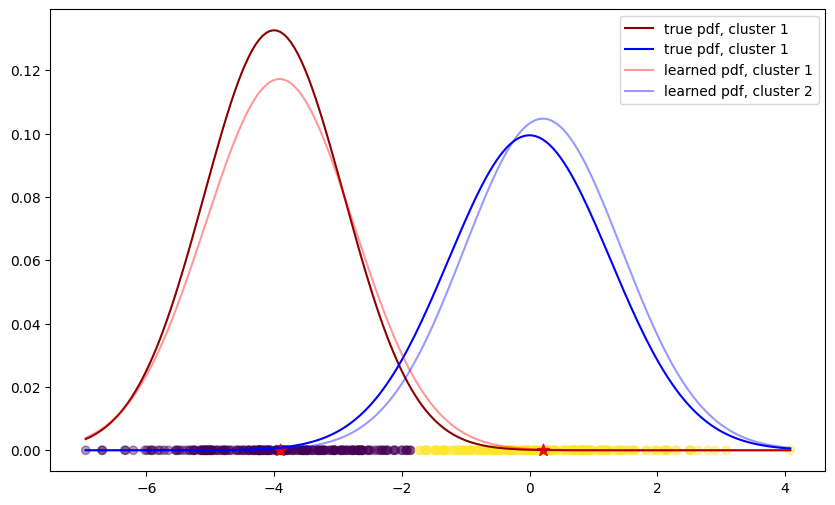

In [7]:
plt.figure(figsize=(10,6))

# true 1-D data
plt.scatter(C[:,0],
            np.zeros(C.shape[0]),
            c=y_pred,
            alpha=0.4)

# true normal distribution
plt.plot(bins, gauss_pdf(bins, mean1, var1), color='darkred', label='true pdf, cluster 1')
plt.plot(bins, gauss_pdf(bins, mean2, var2), color='b', label='true pdf, cluster 1')

# forecast distribution
plt.plot(bins, gauss_pdf(bins, means[0][0], covariances[0][0][0]), 
         alpha=0.4,
         color='r', label='learned pdf, cluster 1')

plt.plot(bins, gauss_pdf(bins, means[1][0], covariances[1][0][0]), 
         alpha=0.4,
         color='b', label='learned pdf, cluster 2')

# predicted mean
plt.scatter(means[:,0],
            np.zeros(len(means[:,0])),
            marker='*',
            color='r',
            s=80)
plt.legend(loc='best')
plt.show()

#### Step 6: Implementation in Python 

1) initialize hyperparameters

In [13]:
k = 2

weights = np.ones((k)) / k
print(f'initial weights: {weights}')

C = C.flatten()
means = np.random.choice(C, k)
print(f'initial means: {means}')

variances = np.random.random_sample(k)
print(f'initial variances: {variances}')

initial weights: [0.5 0.5]
initial means: [0.68161577 0.28704536]
initial variances: [0.96605568 0.76219559]


2) build the algorithm in python

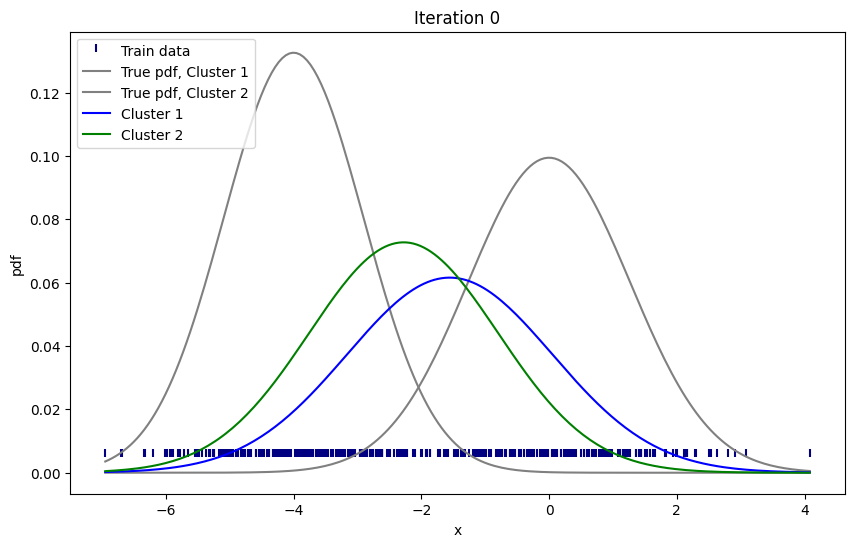

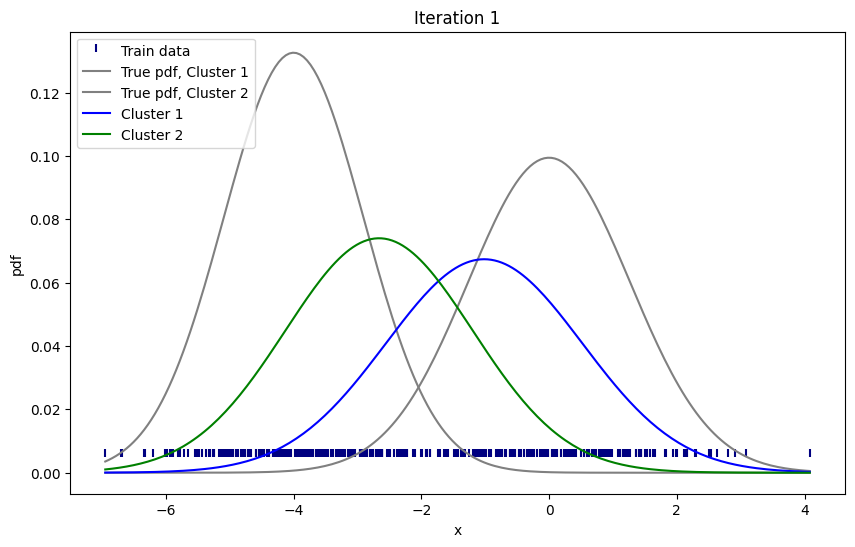

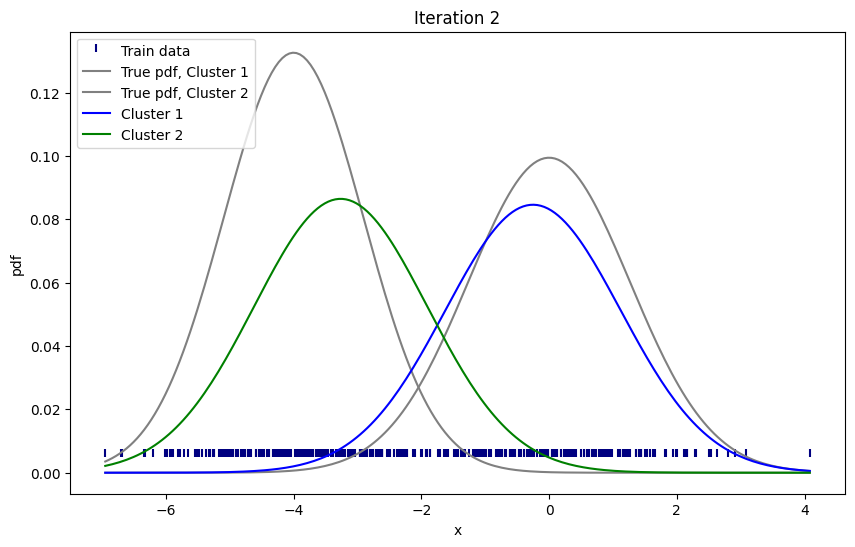

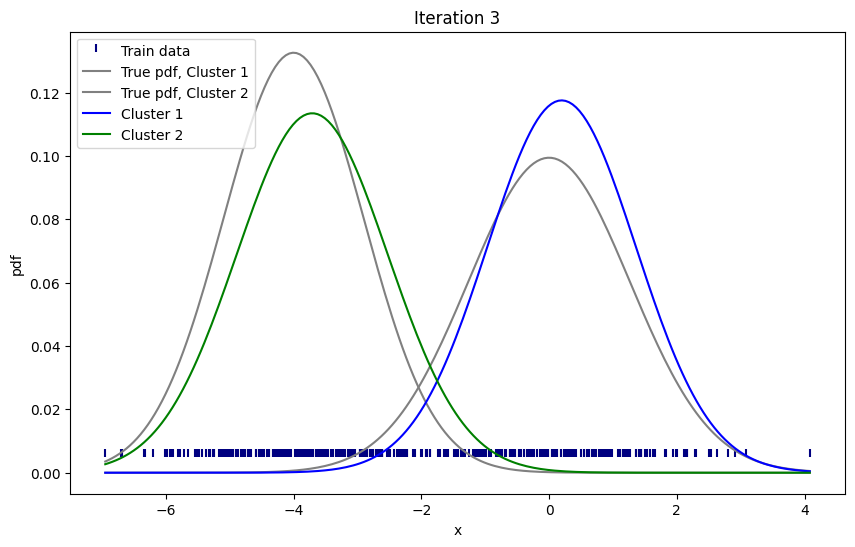

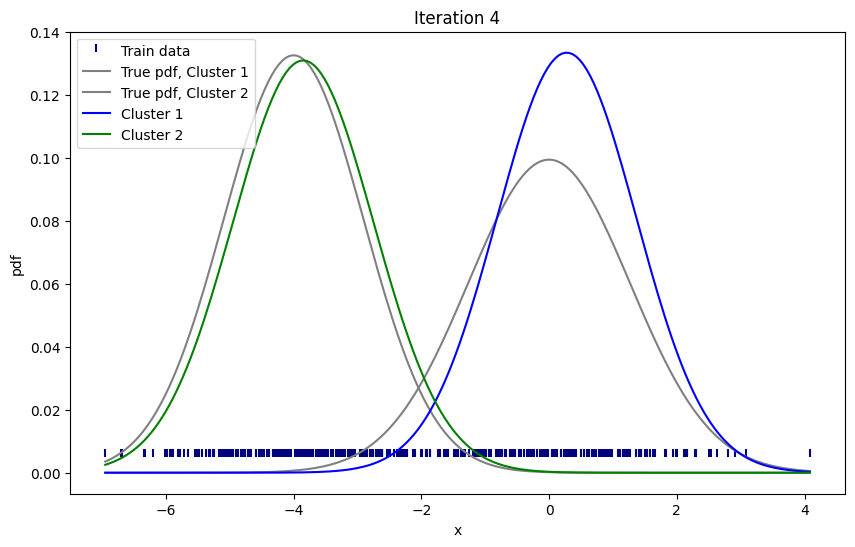

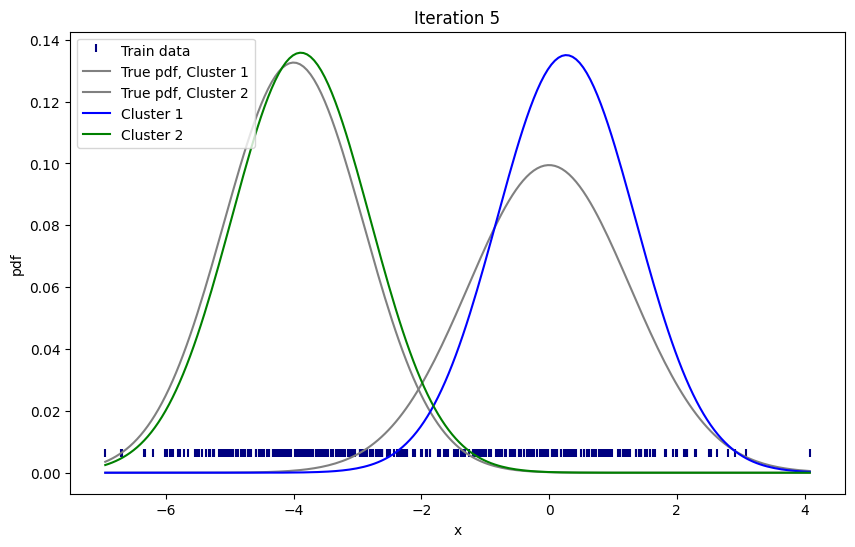

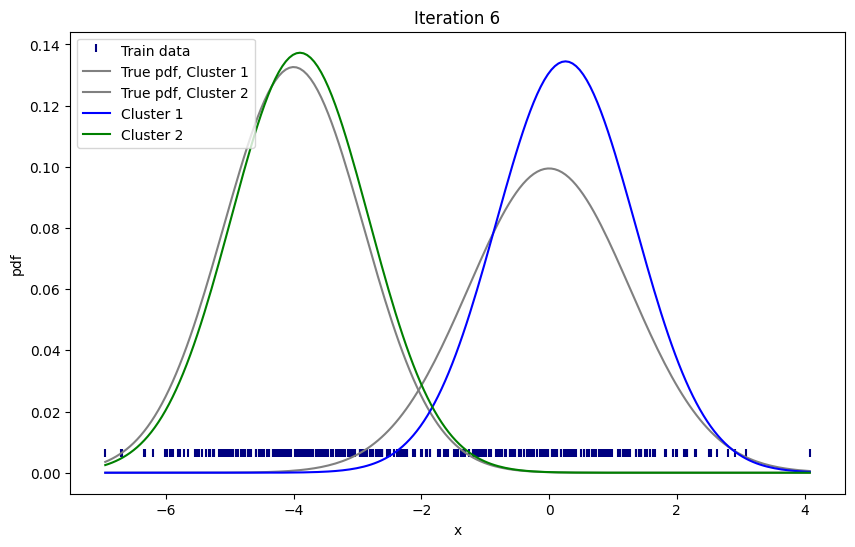

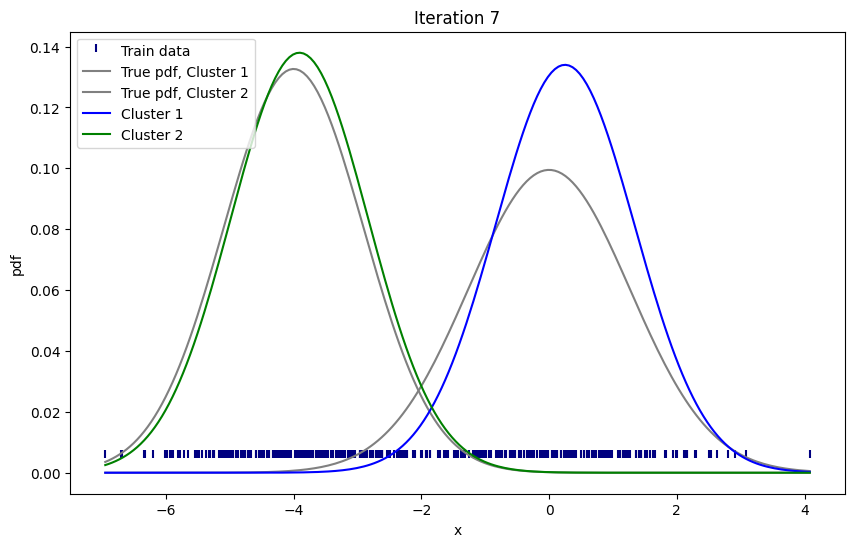

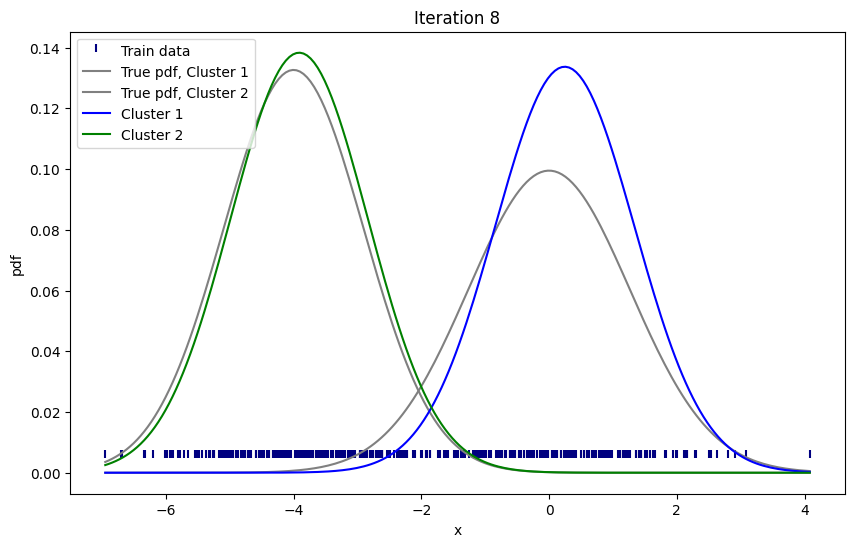

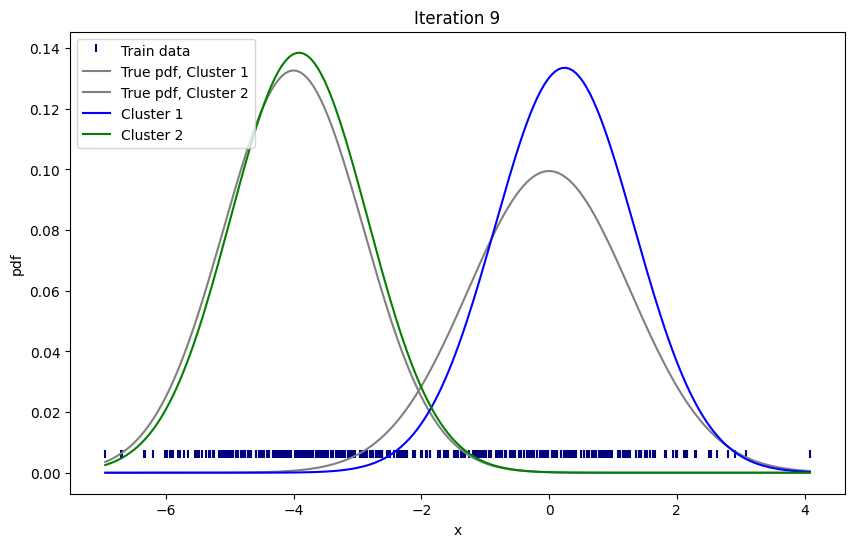

In [ ]:
# A tiny constant used to prevent 'division by zero' errors during calculations
eps = 1e-8

# set number of iterations
for iteration in range(10):
    # 1) calculate the likelihood of each observation ci
    likelihood = []
    for j in range(k):
        likelihood.append(gauss_pdf(C, means[j], np.sqrt(variances[j])))
    likelihood = np.array(likelihood)

    # 2) The Expectation (E) step
    # calcualte the b_i_j, the membership score, the probabilities of the data to have been generated by each gaussian
    b = []
    for j in range(k):
        b.append((likelihood[j] * weights[j]) / np.sum([likelihood[i] * weights[i] for i in range(k)], axis=0) + eps)
    
    # 3) The Maximization (M) step
    # update the mean and variance
    for j in range(k):
        # update the mean
        means[j] = np.sum(b[j] * C) / (np.sum(b[j] + eps))

        # update the variance
        variances[j] = np.sum(b[j] * np.square(C - means[j])) / (np.sum(b[j] + eps))

        # update the weights, the weight si the sum of b_i_j
        weights[j] = np.sum(b[j]) / len(C)
    

    # Plotting
    if iteration % 1 == 0:
        plt.figure(figsize=(10,6))
        # plot C data
        plt.title("Iteration {}".format(iteration))
        plt.scatter(C, [0.005] * len(C), color='navy', s=30, marker=2, label="Train data")
        # plot true pdf
        plt.plot(bins, gauss_pdf(bins, mean1, var1), color='grey', label="True pdf, Cluster 1")
        plt.plot(bins, gauss_pdf(bins, mean2, var2), color='grey', label="True pdf, Cluster 2")
        # plot estimated pdf
        plt.plot(bins, gauss_pdf(bins, means[0], np.sqrt(variances[0])), color='blue', label="Cluster 1")
        plt.plot(bins, gauss_pdf(bins, means[1], np.sqrt(variances[1])), color='green', label="Cluster 2")
        # add labels and legend
        plt.xlabel("x")
        plt.ylabel("pdf")
        plt.legend(loc='upper left')
        plt.show()


#### **Below shows two dimensions samples - example for LLM Gemma 4:**

Learned Means:
 [[-2.5236435   9.06078275]
 [ 4.56450793  1.95057788]]

Learned Cluster Weights (phi):
 [0.49948043 0.50051957]


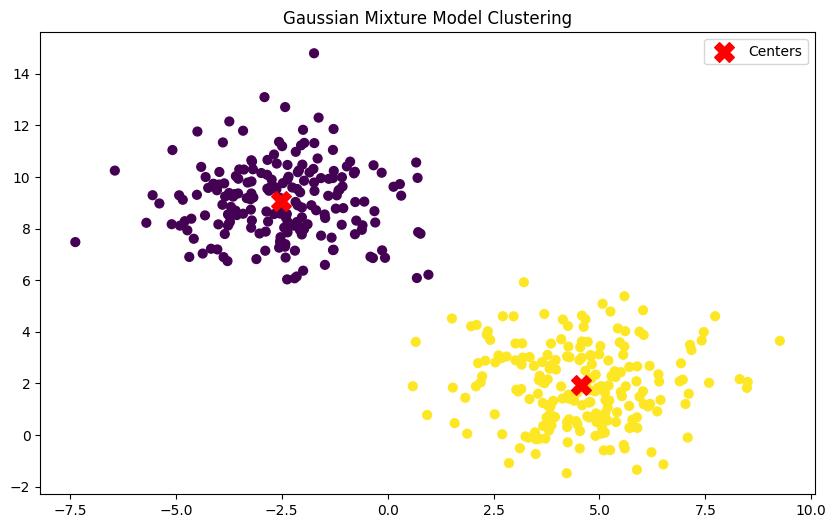

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
from sklearn.datasets import make_blobs

# 1. GENERATE SYNTHETIC DATA
# We create 400 points belonging to 2 clusters (centers)
# 'cluster_std' is set high so the clusters overlap (making it a challenge for GMM)
X, y_true = make_blobs(n_samples=400, centers=2, cluster_std=1.5, random_state=42)

# 2. INITIALIZE THE GMM
# n_components: The number of clusters (K) we want to find
# covariance_type: 'full' allows the clusters to be any elliptical shape
gmm = GaussianMixture(n_components=2, covariance_type='full', random_state=42)

# 3. THE "FIT" STEP (This runs the EM Algorithm internally)
# The algorithm performs E-steps and M-steps until convergence
gmm.fit(X)

# 4. PREDICT AND EXTRACT PARAMETERS
# Predict the cluster label for each point (Hard Clustering)
labels = gmm.predict(X)

# Get the "Soft" probabilities (The b^i_j values we discussed!)
# This returns an array of shape (n_samples, n_components)
probs = gmm.predict_proba(X)

# Retrieve the learned parameters (The mu and sigma we discussed!)
means = gmm.means_
covariances = gmm.covariances_
weights = gmm.weights_

print("Learned Means:\n", means)
print("\nLearned Cluster Weights (phi):\n", weights)

# 5. VISUALIZATION
plt.figure(figsize=(10, 6))

# Plot the data points, colored by their predicted cluster label
plt.scatter(X[:, 0], X[:, 1], c=labels, s=40, cmap='viridis', zorder=2)

# Plot the centers (means) of the clusters
plt.scatter(means[:, 0], means[:, 1], c='red', s=200, marker='X', label='Centers', zorder=3)

plt.title("Gaussian Mixture Model Clustering")
plt.legend()
plt.show()
